In [1]:
import os 
import pandas as pd
root = "/".join(os.getcwd().split("/")[:-3])
data_path = os.path.join(root, "data", "splits")
data = {
    file.split(".")[0] : pd.read_csv(os.path.join(data_path, file), index_col= 'timestamp', parse_dates=['timestamp']) for file in os.listdir(data_path)
}

In [2]:
from sklearn.dummy import DummyRegressor
from performance import rmse_mae_comparison, regression_preds_comparison, time_based_pred_comparison
dummy = DummyRegressor(strategy="mean").fit(data['X_train'], data['y_train'])
rmse_mae_comparison(
    model = dummy,
    train_features = data['X_train'],
    val_features = data['X_val'],
    train_target = data['y_train'],
    val_target = data['y_val']
)

,train,validation,diff
rmse,1125.6159,1217.5811,-91.9652
mae,806.3512,1092.6582,-286.3070


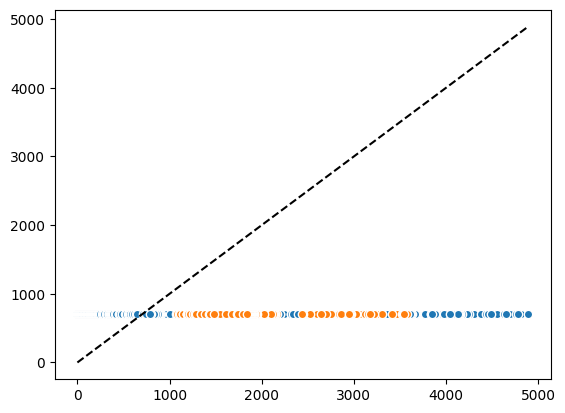

In [28]:
import matplotlib.pyplot as plt
import math
pred_train = dummy.predict(data['X_train'])
pred_val = dummy.predict(data['X_val'])
max_value = max(max(pred_train), max(pred_val), max(data['y_train'].values), max(data['y_val'].values))[0]
plt.scatter(data['y_train'], pred_train, edgecolors = "white")
plt.scatter(data['y_val'], pred_val, edgecolors = "white")
plt.plot([0, max_value], [0, max_value], color = 'black', linestyle = "--")

(<Figure size 700x500 with 1 Axes>,
 <Axes: title={'center': 'Time based predictions'}, xlabel='date', ylabel='price'>)

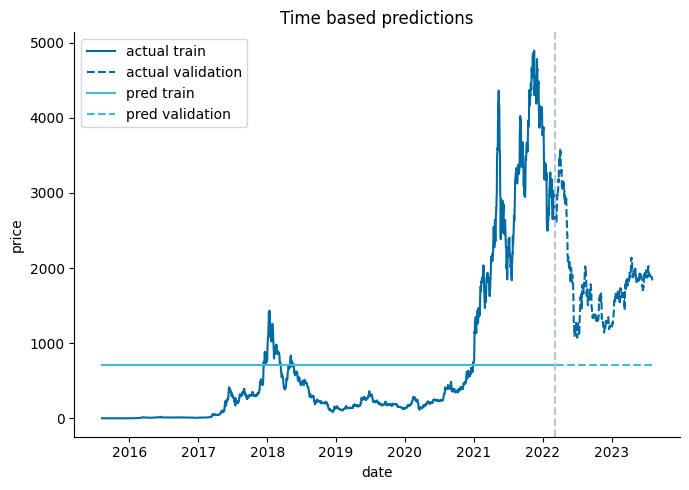

In [3]:
time_based_pred_comparison(
    model = dummy,
    train_features = data['X_train'],
    val_features = data['X_val'],
    train_target = data['y_train'],
    val_target = data['y_val']
)

(<Figure size 700x500 with 1 Axes>,
 <Axes: xlabel='Actual', ylabel='Prediction'>)

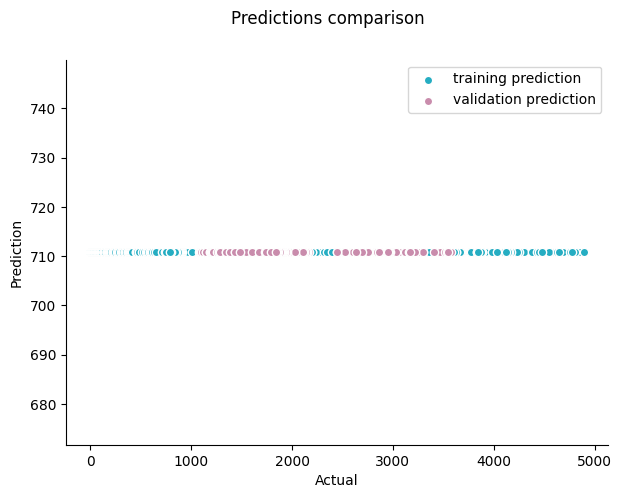

In [10]:
regression_preds_comparison(
    model = dummy,
    train_features = data['X_train'],
    val_features = data['X_val'],
    train_target = data['y_train'],
    val_target = data['y_val']
)